# =====================================================
# MACHINE LEARNING - REGRESI (Tugas Kecil)
# =====================================================
# Nama : Munirotun Ni'mah
# NIM  : F1G123010
# Judul:
# Perbandingan Algoritma Linear Regression, Decision Tree,
# dan Random Forest dalam Prediksi Penjualan Mobil BMW
#
# Dataset: BMW Global Sales
# Tujuan: Memprediksi jumlah penjualan mobil (Sales)
# Evaluasi: MAE, MSE, RMSE, R2 Score
# =====================================================

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Data

In [ ]:
data = pd.read_csv("bmw_global_sales_dataset.csv")

data.head()

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


Data Understanding

In [ ]:
print("Shape:", data.shape)

data.info()

print("\nStatistik Deskriptif:")
print(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

Shape: (1000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   object 
 3   model                  1000 non-null   object 
 4   segment                1000 non-null   object 
 5   engine_type            1000 non-null   object 
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), object(4)
memo

Data Preprocessing

In [ ]:
# Missing value
for col in data.select_dtypes(include=['float64','int64']).columns:
    data[col] = data[col].fillna(data[col].median())

# Encoding
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])

# Feature Engineering
data['price_performance'] = data['price_usd'] / (data['competition_index']+1)
data['marketing_efficiency'] = data['marketing_spend_usd'] / (data['units_sold']+1)

# Drop kolom (aman)
data = data.drop(['year','month'], axis=1, errors='ignore')

EDA

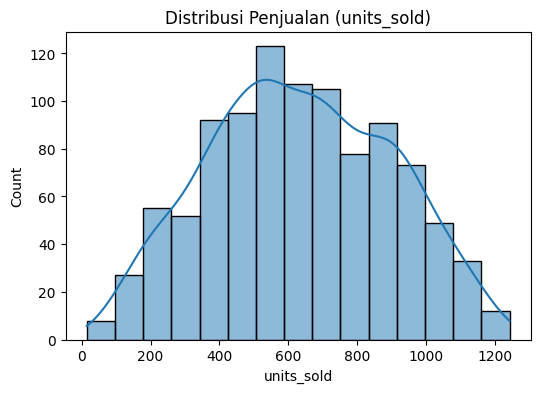

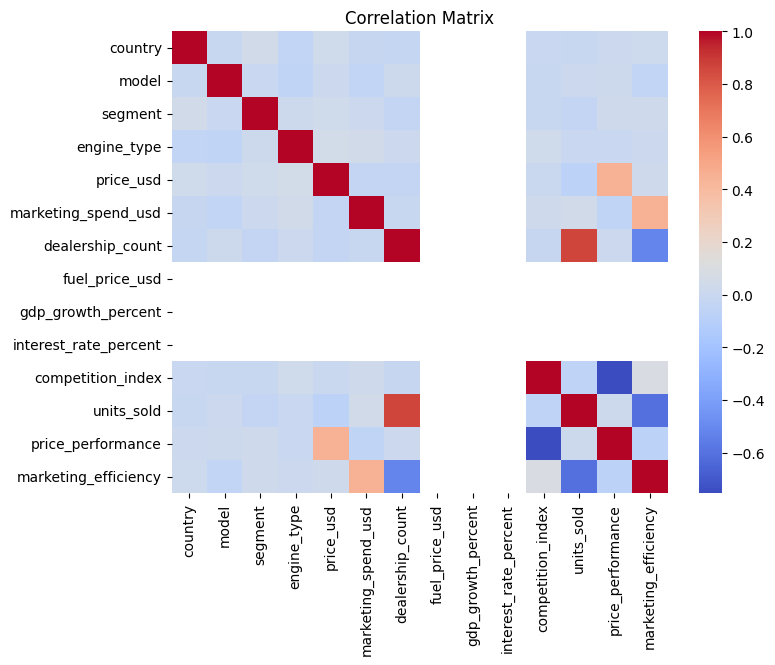

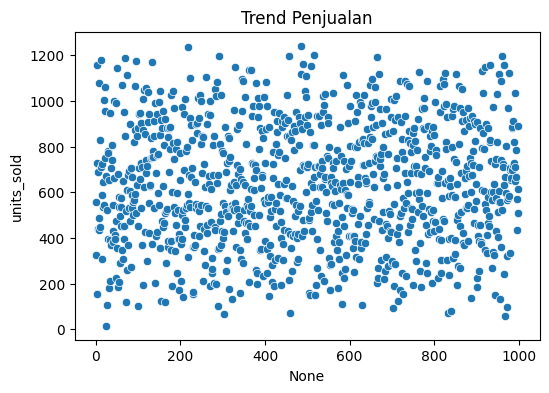

In [ ]:
# Distribusi target
plt.figure(figsize=(6,4))
sns.histplot(data['units_sold'], kde=True)
plt.title("Distribusi Penjualan (units_sold)")
plt.show()

# Korelasi
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# tambahan insight
plt.figure(figsize=(6,4))
sns.scatterplot(x=data.index, y=data['units_sold'])
plt.title("Trend Penjualan")
plt.show()

Fitur dan Target

In [ ]:
X = data.drop("units_sold", axis=1)
y = data["units_sold"]

print("Target:", y.name)

Target: units_sold


Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Variasi Split

In [ ]:
splits = {
    "70:30":0.3,
    "80:20":0.2,
    "90:10":0.1
}

Hyperparameter

In [ ]:
dt_param = {
    'max_depth':[5,10,20,None],
    'min_samples_split':[2,5,10]
}

rf_param = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

Training, Tuning, Evaluasi

In [ ]:
results = []

best_rf_model = None
best_r2 = -999

for split_name, test_size in splits.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=42
    )

    # =====================
    # Linear Regression
    # =====================
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)

    results.append([
        "Linear Regression", split_name,
        mean_absolute_error(y_test, pred_lr),
        mean_squared_error(y_test, pred_lr),
        np.sqrt(mean_squared_error(y_test, pred_lr)),
        r2_score(y_test, pred_lr)
    ])


    # =====================
    # Decision Tree
    # =====================
    dt = GridSearchCV(DecisionTreeRegressor(), dt_param, cv=5)
    dt.fit(X_train, y_train)
    pred_dt = dt.predict(X_test)

    results.append([
        "Decision Tree", split_name,
        mean_absolute_error(y_test, pred_dt),
        mean_squared_error(y_test, pred_dt),
        np.sqrt(mean_squared_error(y_test, pred_dt)),
        r2_score(y_test, pred_dt)
    ])


    # =====================
    # Random Forest
    # =====================
    rf = GridSearchCV(RandomForestRegressor(), rf_param, cv=5, n_jobs=-1)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    r2 = r2_score(y_test, pred_rf)

    # 🔥 SIMPAN MODEL TERBAIK
    if r2 > best_r2:
        best_r2 = r2
        best_rf_model = rf.best_estimator_

    results.append([
        "Random Forest", split_name,
        mean_absolute_error(y_test, pred_rf),
        mean_squared_error(y_test, pred_rf),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        r2
    ])

Hasil Model

In [ ]:
results_df = pd.DataFrame(results,columns=[
    "Model","Split","MAE","MSE","RMSE","R2"
])

results_df

,Model,Split,MAE,MSE,RMSE,R2
0,Linear Regression,70:30,94.114528,12739.386367,112.868890,0.810343
1,Decision Tree,70:30,70.550404,8663.871815,93.079922,0.871017
2,Random Forest,70:30,59.600367,6950.415370,83.369151,0.896526
3,Linear Regression,80:20,95.884989,13134.481069,114.605764,0.807850
4,Decision Tree,80:20,79.470392,11549.890102,107.470415,0.831032
5,Random Forest,80:20,59.870050,6369.235073,79.807488,0.906822
6,Linear Regression,90:10,96.251143,12901.025709,113.582682,0.811420
7,Decision Tree,90:10,81.064457,12526.001355,111.919620,0.816902
8,Random Forest,90:10,60.232950,6090.892141,78.044168,0.910967


Model Terbaik

In [ ]:
best_model = results_df.loc[results_df['R2'].idxmax()]

print("Model Terbaik:")
print(best_model)

Model Terbaik:
Model    Random Forest
Split            90:10
MAE           60.23295
MSE        6090.892141
RMSE         78.044168
R2            0.910967
Name: 8, dtype: object


Visualisasi

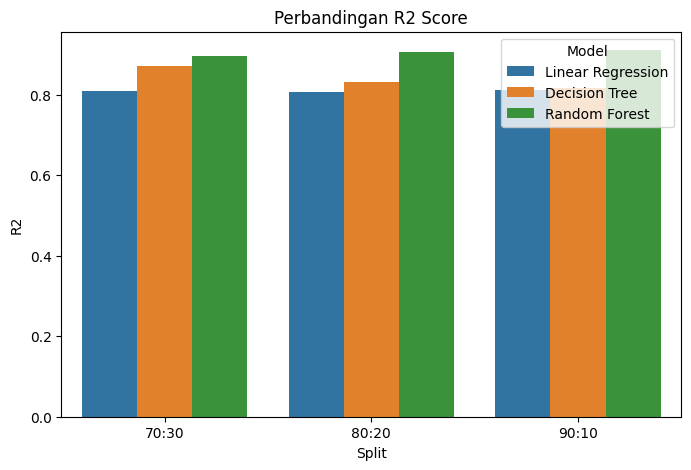

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(x="Split",y="R2",hue="Model",data=results_df)

plt.title("Perbandingan R2 Score")
plt.show()

Penjelasan R2

In [ ]:
print("\nPENJELASAN R2:")
print("R2 Score digunakan untuk mengukur seberapa baik model dalam memprediksi.")
print("Nilai mendekati 1 berarti model sangat baik.")


PENJELASAN R2:
R2 Score digunakan untuk mengukur seberapa baik model dalam memprediksi.
Nilai mendekati 1 berarti model sangat baik.


Interpretasi

In [ ]:
print("\nINTERPRETASI:")
print("Model terbaik adalah yang memiliki R2 tertinggi.")
print("Error kecil (MAE, RMSE) menunjukkan prediksi akurat.")


INTERPRETASI:
Model terbaik adalah yang memiliki R2 tertinggi.
Error kecil (MAE, RMSE) menunjukkan prediksi akurat.


Kesimpulan

In [ ]:
print("\nKESIMPULAN:")
print(f"Model terbaik: {best_model['Model']}")
print(f"R2 Score: {best_model['R2']:.3f}")


KESIMPULAN:
Model terbaik: Random Forest
R2 Score: 0.911


In [ ]:
print(X.columns)

Index(['country', 'model', 'segment', 'engine_type', 'price_usd',
       'marketing_spend_usd', 'dealership_count', 'fuel_price_usd',
       'gdp_growth_percent', 'interest_rate_percent', 'competition_index',
       'price_performance', 'marketing_efficiency'],
      dtype='object')


In [ ]:
# ==========================
# DEPLOYMENT SEDERHANA (PREDIKSI DATA BARU)
# ==========================

import pandas as pd

# URUTAN HARUS SAMA PERSIS DENGAN X.columns
data_baru = pd.DataFrame([[
    1,      # country
    2,      # model
    1,      # segment
    0,      # engine_type
    30000,  # price_usd
    5000,   # marketing_spend_usd
    20,     # dealership_count
    0.97,   # fuel_price_usd
    6.29,   # gdp_growth_percent
    1.2,    # interest_rate_percent
    5,      # competition_index
    30000/(5+1),   # price_performance
    5000/(500+1)   # marketing_efficiency
]], columns=X.columns)

# scaling
data_baru_scaled = scaler.transform(data_baru)

# prediksi pakai model terbaik
prediksi = best_rf_model.predict(data_baru_scaled)

print("Prediksi jumlah penjualan:", int(prediksi[0]))

Prediksi jumlah penjualan: 401
